## **Estimating Shapley Value Feature Attributions**

This Lab turns the taxonomy of Shapley-value estimators (Chen, Covert, Lundberg & Lee, 2023 and related work) into **hands-on experiments**. Each module makes one specific conceptual point tangible with runnable code, rather than leaving it abstract.


In [1]:
# Core scientific stack is preinstalled in Colab; we only need to add SHAP-related libraries.
!pip install -q shap shapiq xgboost


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 17.0 MB/s eta 0:00:00


In [33]:
import itertools
import math
from copy import deepcopy
from dataclasses import dataclass
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from itertools import combinations
import time

rng_global = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

## **Exercise 1 : Exact vs. sampled Shapley values**

We build a small **toy cooperative game** over $n=8$ "players" (features), small enough to
brute-force enumerate all $2^n$ coalitions and get the *exact* Shapley value. We then compare
two sampling-based estimators from the semivalue / random-order family:

- **ApproSemivalue** (Castro, Gómez & Tejada, 2009) — samples a random subset per player, independently.
- **ApproShapley** (Castro, Gómez & Tejada, 2009) — samples a random *permutation*, and updates
  every player's estimate from the same walk (query reuse).

The point of this module: both are unbiased estimators of the *same* quantity, but they behave
differently as a function of the sampling budget.


In [3]:
# --- Toy cooperative game with mild synergy (not purely additive) ---
n = 8
weights = rng_global.uniform(0.2, 1.0, size=n)

def v(S, weights=weights):
    """Coalitional game value for subset S (a set or list of player indices)."""
    S = tuple(sorted(S))
    if len(S) == 0:
        return 0.0
    w = weights[list(S)].sum()
    synergy = 0.15 * sum(weights[j1] * weights[j2] for j1, j2 in combinations(S, 2))
    return w + synergy

players = list(range(n))
print("Toy game with", n, "players. v(full coalition) =", round(v(players), 3))


Toy game with 8 players. v(full coalition) = 6.306


In [4]:
# --- Exact Shapley value via brute-force enumeration (feasible only because n is small) ---
def exact_shapley(players, v):
    n = len(players)
    phi = np.zeros(n)
    for i in players:
        others = [p for p in players if p != i]
        total = 0.0
        for r in range(len(others) + 1):
            for S in combinations(others, r):
                weight = (math.factorial(r) * math.factorial(n - r - 1)) / math.factorial(n)
                total += weight * (v(set(S) | {i}) - v(set(S)))
        phi[i] = total
    return phi

phi_exact = exact_shapley(players, v)
print("Exact Shapley values:", phi_exact)
print("Sum of attributions:  ", round(phi_exact.sum(), 4))
print("v(N) - v(empty):      ", round(v(players) - v([]), 4))
print("(these two should match exactly -- this IS the efficiency axiom)")


Exact Shapley values: [0.9284 0.5532 0.3129 0.2869 1.1039 1.2017 0.8979 1.0209]
Sum of attributions:   6.3057
v(N) - v(empty):       6.3057
(these two should match exactly -- this IS the efficiency axiom)


## **Implementation of ApproSemivalue and ApproShapley and test**

In [5]:
# --- ApproSemivalue: independent subset sampling per player ---
def approsemivalue(players, v, m_per_player, rng):
    n = len(players)
    phi = np.zeros(n)

    for i in players:
        others = [p for p in players if p != i]   # all players except i (the "pool" to draw coalitions from)
        contribs = []

        for _ in range(m_per_player):      # draw m_per_player random coalitions to estimate phi_i
            r = rng.integers(0, len(others) + 1)
            # ^ pick a random coalition SIZE r, uniformly from 0 to len(others) inclusive.
            #   This is the key sampling choice: instead of weighting sizes by the Shapley
            #   combinatorial factor, sizes are drawn uniformly at random. That's what makes
            #   this an "ApproSemivalue" estimator rather than exact Shapley — different size-weighting
            #   schemes correspond to different semivalues (Shapley, Banzhaf, etc.).

            S = set(rng.choice(others, size=r, replace=False)) if r > 0 else set()
            # ^ given the chosen size r, randomly select r players (without replacement) from
            #   "others" to form coalition S. If r == 0, S is just the empty set (guard needed
            #   because rng.choice with size=0 on a list can behave oddly / is just wasteful).

            contribs.append(v(S | {i}) - v(S))
            # ^ compute player i's MARGINAL CONTRIBUTION to this particular coalition:
            #   the value of the game with i added to S, minus the value without i.
            #   v(...) is the characteristic/value function (e.g., model output with that
            #   subset of features "active", others replaced by marginal/background draws).

        phi[i] = np.mean(contribs)
        # ^ average the sampled marginal contributions to get a Monte Carlo estimate
        #   of player i's semivalue (this approximates the expectation over coalition
        #   sizes/subsets that defines phi_i in the semivalue family).

    return phi                             # return the vector of estimated attributions, one per player


In [6]:
# --- ApproShapley: permutation sampling, ALL players updated per sampled permutation ---
def approshapley(players, v, num_perms, rng):
    n = len(players)                       # total number of players (features)
    phi = np.zeros(n)                      # accumulator for each player's total marginal contribution

    for _ in range(num_perms):             # repeat over num_perms randomly sampled orderings
        perm = rng.permutation(players)
        # ^ draw one random permutation (ordering) of all players — e.g., [2, 0, 3, 1].
        #   This represents one random "arrival order" in which players join the coalition.

        S = set()                          # coalition starts empty before anyone has "arrived"
        prev_value = v(S)                  # value of the empty coalition, v(∅) — baseline for this permutation

        for p in perm:                     # walk through the permutation player by player, in order
            new_value = v(S | {p})
            # ^ value of the coalition AFTER player p joins (S with p added)

            phi[p] += (new_value - prev_value)
            # ^ player p's marginal contribution in this specific permutation is the value
            #   it adds by joining at this exact position: v(S ∪ {p}) - v(S).
            #   This gets ACCUMULATED into phi[p] — added to contributions from p's position
            #   in every other sampled permutation too.

            S = S | {p}                    # p has now "joined" — update the coalition
            prev_value = new_value          # cache new_value as the baseline for the next player in line
                                            # (avoids recomputing v(S) redundantly)

    return phi / num_perms                 # average each player's accumulated contribution over
                                            # all sampled permutations → Monte Carlo estimate of phi_i

In [7]:
# Quick sanity check at a moderate budget
rng1 = np.random.default_rng(1)
phi_sv_demo = approsemivalue(players, v, 300, rng1)
phi_ro_demo = approshapley(players, v, 300, rng1)
print("SV  estimate error (L2):", np.linalg.norm(phi_sv_demo - phi_exact))
print("RO  estimate error (L2):", np.linalg.norm(phi_ro_demo - phi_exact))

SV  estimate error (L2): 0.018861254654415675
RO  estimate error (L2): 0.025281502396773424


## **Question 1 : compare the convergence rate of these two estimators and comment**

In [8]:
# --- Convergence experiment: error vs. sampling budget, averaged over repeated trials ---
budgets = [5, 10, 25, 50, 100, 250, 500, 1000]
n_trials = 15

sv_errors = []
ro_errors = []

for m in budgets:
    sv_trial_errs, ro_trial_errs = [], []
    for t in range(n_trials):
        r = np.random.default_rng(1000 + t)
        phi_sv = approsemivalue(players, v, m, r)
        phi_ro = approshapley(players, v, m, r)
        sv_trial_errs.append(np.linalg.norm(phi_sv - phi_exact))
        ro_trial_errs.append(np.linalg.norm(phi_ro - phi_exact))
    sv_errors.append(np.mean(sv_trial_errs))
    ro_errors.append(np.mean(ro_trial_errs))

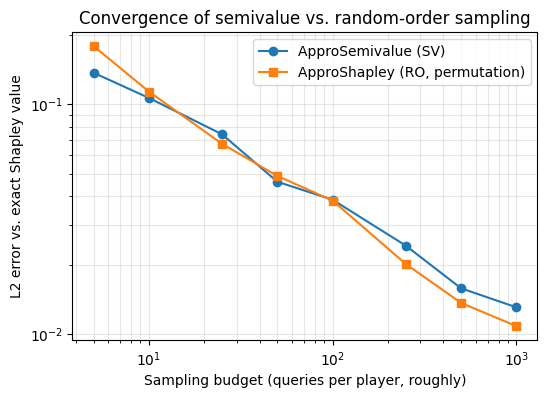

In [9]:
plt.figure(figsize=(6, 4))
plt.loglog(budgets, sv_errors, "o-", label="ApproSemivalue (SV)")
plt.loglog(budgets, ro_errors, "s-", label="ApproShapley (RO, permutation)")
plt.xlabel("Sampling budget (queries per player, roughly)")
plt.ylabel("L2 error vs. exact Shapley value")
plt.title("Convergence of semivalue vs. random-order sampling")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()


## **Question 2 : the efficiency axiom**

The exact Shapley value always satisfies $\sum_i \phi_i = v(N) - v(\emptyset)$ (the *efficiency*
or *local accuracy* axiom). Random-order (permutation) sampling satisfies this **exactly**, even
from a single sampled permutation, because the marginal contributions along one permutation
telescope to the total. Semivalue sampling only satisfies it **in expectation**, as the sample
size grows.

Check it!

In [10]:
target = v(players) - v([])
print("Target (v(N) - v(empty)):", round(target, 4))
print()

for m in [1, 5, 20, 100]:
    r = np.random.default_rng(42)
    phi_ro = approshapley(players, v, m, r)
    phi_sv = approsemivalue(players, v, m, r)
    print(f"m={m:4d}  |  RO sum = {phi_ro.sum():.4f} (diff {phi_ro.sum()-target:+.2e})"
          f"   |  SV sum = {phi_sv.sum():.4f} (diff {phi_sv.sum()-target:+.2e})")


Target (v(N) - v(empty)): 6.3057

m=   1  |  RO sum = 6.3057 (diff +0.00e+00)   |  SV sum = 6.4689 (diff +1.63e-01)
m=   5  |  RO sum = 6.3057 (diff +0.00e+00)   |  SV sum = 6.0060 (diff -3.00e-01)
m=  20  |  RO sum = 6.3057 (diff +0.00e+00)   |  SV sum = 6.3021 (diff -3.63e-03)
m= 100  |  RO sum = 6.3057 (diff +0.00e+00)   |  SV sum = 6.2164 (diff -8.94e-02)


Notice that the **RO sum matches the target to floating-point precision at every budget**,
including $m=1$ (a single sampled permutation!), while the **SV sum only gets close as $m$ grows**.
This is a direct, visible consequence of which characterization of the Shapley value each
estimator samples from.


## **Exercise 2 : KernelSHAP as weighted least squares, from scratch**


KernelSHAP (Lundberg & Lee, 2017) reformulates the Shapley value as the solution to a
**weighted least-squares regression** over sampled coalitions. We implement this by hand on our
toy game, then validate it against the official `shap` library on a real linear model (where
we can also compare to the *exact* linear SHAP formula).


In [11]:
def kernelshap_manual(players, v, num_samples, rng):
    """KernelSHAP built from scratch: sample coalitions, solve a weighted least-squares
    regression using the Shapley kernel, and enforce the efficiency constraint exactly
    (the standard reduced-regression trick)."""
    n = len(players)
    v_empty = v(set())              # v(∅): baseline value with no features "active"
    v_full = v(set(players))        # v(N): value with ALL features active (the actual prediction)
    # These are the two "anchor" values needed both to build regression targets
    # and to enforce the efficiency constraint (attributions must sum to v_full - v_empty).

    rows, targets, weights = [], [], []   # will hold the regression design matrix, y-values, and Shapley-kernel weights

    for _ in range(num_samples):          # Monte Carlo sample num_samples coalitions
        size = rng.integers(1, n)
        # ^ draw a random coalition SIZE strictly between 1 and n-1 (rng.integers(1, n) excludes n).
        #   Empty (size=0) and full (size=n) coalitions are deliberately excluded because
        #   the Shapley kernel weight W(S) is mathematically infinite/undefined at those
        #   sizes (division by s*(n-s) blows up when s=0 or s=n) — they're handled separately
        #   via the efficiency constraint instead of being sampled.

        S = set(rng.choice(players, size=size, replace=False))
        # ^ randomly select `size` players (without replacement) to form coalition S

        z = np.zeros(n)
        z[list(S)] = 1
        # ^ encode S as a binary indicator vector z ∈ {0,1}^n: 1 if player is "in" the
        #   coalition, 0 if "out". This z is one ROW of the regression design matrix —
        #   KernelSHAP's trick is that the Shapley value can be recovered as the coefficients
        #   of a linear model g(z) = phi_0 + sum(phi_i * z_i) fit to these binary vectors.

        s = len(S)
        w = (n - 1) / (math.comb(n, s) * s * (n - s))
        # ^ the SHAPLEY KERNEL weight π(S): this specific weighting function is what makes
        #   the weighted-least-squares solution converge to the exact Shapley values
        #   (as opposed to LIME's arbitrary/heuristic kernel). It up-weights very small and
        #   very large coalitions (which are more informative about individual marginal
        #   effects) and down-weights mid-sized coalitions.

        rows.append(z)
        targets.append(v(S))      # the "y" value for this row: model's value function output for S
        weights.append(w)         # the Shapley-kernel weight for this row

    Z = np.array(rows)     # (num_samples x n) binary design matrix
    y = np.array(targets)  # (num_samples,) target values v(S) for each sampled coalition
    W = np.array(weights)  # (num_samples,) Shapley kernel weights, one per sampled row

    # Enforce efficiency constraint by reducing to n-1 free variables (standard trick)
    y_adj = y - v_empty
    # ^ shift targets so the regression is centered at v(∅) = 0 (i.e., we're now solving for
    #   values relative to the empty-coalition baseline, matching how Shapley values are defined)

    total = v_full - v_empty
    # ^ total value to be "distributed" among players — the efficiency axiom requires
    #   sum(phi_i) == v_full - v_empty exactly, so this quantity anchors that constraint

    Z_reduced = Z[:, :-1] - Z[:, -1:].reshape(-1, 1)
    # ^ THE REDUCTION TRICK: instead of solving for all n unknowns (phi_1...phi_n) with an
    #   explicit linear constraint (sum = total), substitute phi_n = total - sum(phi_1..phi_{n-1})
    #   directly into the regression equation. This algebraically eliminates player n as a free
    #   variable — each remaining feature's column is replaced by (its own indicator minus the
    #   last player's indicator), which is what falls out of that substitution. This guarantees the
    #   efficiency constraint holds EXACTLY (not approximately) rather than needing constrained
    #   least-squares or a Lagrange multiplier.

    y_reduced = y_adj - Z[:, -1] * total
    # ^ correspondingly, the target vector is adjusted for the same substitution — subtracting off
    #   the contribution of the substituted (last) player's term.

    WZ = Z_reduced * np.sqrt(W)[:, None]
    Wy = y_reduced * np.sqrt(W)
    # ^ apply the Shapley kernel weights to both sides of the regression by multiplying by
    #   sqrt(W): this is the standard way to convert a WEIGHTED least-squares problem into an
    #   ordinary least-squares problem solvable by np.linalg.lstsq (since minimizing
    #   sum(W * residual^2) is equivalent to minimizing sum((sqrt(W) * residual)^2)).

    beta_reduced, *_ = np.linalg.lstsq(WZ, Wy, rcond=None)
    # ^ solve the (weighted, reduced) least-squares regression for the n-1 free coefficients.
    #   `*_` discards the other outputs lstsq returns (residuals, rank, singular values) since
    #   they're not needed here.

    phi = np.zeros(n)
    phi[:-1] = beta_reduced
    # ^ first n-1 Shapley value estimates come directly from the regression coefficients

    phi[-1] = total - beta_reduced.sum()
    # ^ the LAST player's value is recovered by the efficiency constraint itself:
    #   phi_n = total - sum(other phi_i), guaranteeing sum(phi) == v_full - v_empty exactly,
    #   with no leftover residual/discrepancy.

    return phi   # array of n Shapley value estimates, one per player

## **Question 1 : test this estimator and calculate the error. Does the estimator satisfy the efficiency axiom?**

In [12]:
rng_wls = np.random.default_rng(2)
phi_wls = kernelshap_manual(players, v, 500, rng_wls)
print("Manual KernelSHAP error vs. exact:", np.linalg.norm(phi_wls - phi_exact))
print("Manual KernelSHAP sum:", round(phi_wls.sum(), 4), " (target:", round(target, 4), ")")

Manual KernelSHAP error vs. exact: 0.08317147955522614
Manual KernelSHAP sum: 6.3057  (target: 6.3057 )


## **Question 2 : Validate against the official `shap` library on a real linear model**

In [13]:
import shap
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y=True)
X, y = X[:150, :4], y[:150]   # keep small & fast for the lab
model = LinearRegression().fit(X, y)
background = X[:30]


In [14]:
# Exact linear SHAP (closed form -- LinearSHAP from the taxonomy's model-specific branch)
linear_explainer = shap.LinearExplainer(model, background)
sv_exact_linear = linear_explainer.shap_values(X[0:1])[0]

# KernelSHAP (model-agnostic, sampled)
kernel_explainer = shap.KernelExplainer(model.predict, background)
sv_kernel = kernel_explainer.shap_values(X[0:1], nsamples=200, silent=True)[0]

print("Exact LinearSHAP:  ", np.round(sv_exact_linear, 4))
print("Sampled KernelSHAP:", np.round(sv_kernel, 4))
print("Max abs difference:", np.abs(sv_exact_linear - sv_kernel).max())


Exact LinearSHAP:   [ -2.4632 -11.8911  49.8781  11.6395]
Sampled KernelSHAP: [ -2.4632 -11.8911  49.8781  11.6395]
Max abs difference: 3.552713678800501e-14


**Try it:** re-run the cell above with `nsamples=20` instead of `200` and see the KernelSHAP
estimate degrade — a direct illustration of the sampling-budget tradeoff.

**Optional extension (LeverageSHAP):** if you have `shapiq` installed, compare
`shapiq.approximator.KernelSHAP` against `shapiq.approximator.LeverageSHAP` at matched query
budgets on the same model, and plot error vs. budget as in Module 1 — this reproduces
(a simplified version of) Musco & Witter's (2025) headline result.


## **Exercise 3 : Marginal vs. conditional Shapley values with correlated features**


This is the most important conceptual experiment for the **feature-removal axis** of the
taxonomy. We build a dataset with two nearly-identical (highly correlated) features, feeding a
model that only *causally* depends on one of them. We then compute Shapley values two ways:

- **Marginal (interventional)** — "absent" features are replaced by independent draws from a
  background sample (what KernelSHAP and TreeSHAP do by default).
- **Conditional** — "absent" features are replaced by draws that respect the *conditional*
  distribution given the observed features (approximated here with a simple k-nearest-neighbors
  scheme, standing in for methods like Aas, Jullum & Løland's Gaussian/copula estimators).

**Prediction before running:** which feature will each version credit?


In [15]:
rng4 = np.random.default_rng(42)
n_samples = 2000
x1 = rng4.normal(0, 1, n_samples)
x2 = x1 + rng4.normal(0, 0.05, n_samples)   # near-duplicate of x1 (r ~ 0.999)
x3 = rng4.normal(0, 1, n_samples)           # independent, causally irrelevant
X_corr = np.column_stack([x1, x2, x3])

In [16]:
def toy_model(X):
    """Model that TRULY depends only on x1 (coefficient 0 on x2), plus a little on x3."""
    return 3 * X[:, 0] + 0 * X[:, 1] + 0.5 * X[:, 2]

In [17]:
X_bg = X_corr[200:1200]
x_test = X_corr[0]
print("Point to explain: x_test =", np.round(x_test, 3))


Point to explain: x_test = [0.305 0.282 0.253]


## **Question 1 : what is the correlation between $X_1$ and $X_2$?**

In [18]:
print("Correlation(x1, x2) =", round(np.corrcoef(x1, x2)[0,1], 4))

Correlation(x1, x2) = 0.9988


## **Question 2 : define Shapley from $v$ for the marginal game and the conditional game**

In [19]:
# Fix ONE shared background draw for all coalition evaluations: this reduces Monte Carlo
# variance a lot and makes the efficiency axiom hold much more tightly (see Module 2).
FIXED_IDX = np.random.default_rng(7).integers(0, X_bg.shape[0], size=300)
FIXED_BG = X_corr[200:1200][FIXED_IDX]


In [20]:
def v_marginal(S, x, model):
    """Marginal game: absent features filled in with INDEPENDENT background draws."""
    n = FIXED_BG.shape[1]
    Z = np.tile(x, (FIXED_BG.shape[0], 1)).astype(float)
    absent = [i for i in range(n) if i not in S]
    if absent:
        Z[:, absent] = FIXED_BG[:, absent]
    return model(Z).mean()

In [21]:
def v_conditional(S, x, X_bg, model, k=150):
    """Conditional game (approximate): absent features filled in using the k nearest
    background points *given the observed features* -- so correlations are respected."""
    n = X_bg.shape[1]
    if len(S) == 0:
        return model(X_bg).mean()
    present = list(S)
    d = np.linalg.norm(X_bg[:, present] - x[present], axis=1)
    nn_idx = np.argsort(d)[:k]
    Z = np.tile(x, (k, 1)).astype(float)
    absent = [i for i in range(n) if i not in S]
    if absent:
        Z[:, absent] = X_bg[nn_idx][:, absent]
    return model(Z).mean()

In [22]:
def shapley_from_v(v_fn, n=3):
    """Exact Shapley value for an arbitrary black-box value function v_fn (n small)."""
    players = list(range(n))
    phi = np.zeros(n)
    for i in players:
        others = [p for p in players if p != i]
        total = 0.0
        for r in range(len(others) + 1):
            for S in combinations(others, r):
                weight = (math.factorial(r) * math.factorial(n - r - 1)) / math.factorial(n)
                total += weight * (v_fn(set(S) | {i}) - v_fn(set(S)))
        phi[i] = total
    return phi



## **Question 3 : test it**

In [23]:
phi_marginal = shapley_from_v(lambda S: v_marginal(S, x_test, toy_model))
phi_conditional = shapley_from_v(lambda S: v_conditional(S, x_test, X_bg, toy_model))

print("Marginal Shapley    (x1, x2, x3):", np.round(phi_marginal, 3),
      " sum:", round(phi_marginal.sum(), 3))
print("Conditional Shapley (x1, x2, x3):", np.round(phi_conditional, 3),
      " sum:", round(phi_conditional.sum(), 3))
print("f(x) - E[f(X)]                  :", round(toy_model(x_test.reshape(1,-1))[0]
                                                   - toy_model(X_bg).mean(), 3))


Marginal Shapley    (x1, x2, x3): [0.947 0.    0.127]  sum: 1.075
Conditional Shapley (x1, x2, x3): [0.499 0.398 0.222]  sum: 1.119
f(x) - E[f(X)]                  : 1.119


## **Summary**

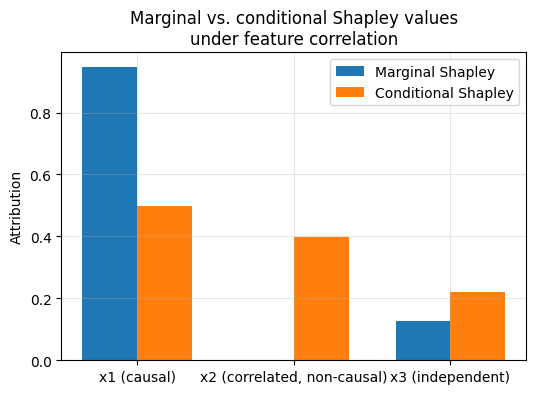

In [24]:
labels = ["x1 (causal)", "x2 (correlated, non-causal)", "x3 (independent)"]
fig, ax = plt.subplots(figsize=(6,4))
width = 0.35
xpos = np.arange(3)
ax.bar(xpos - width/2, phi_marginal, width, label="Marginal Shapley")
ax.bar(xpos + width/2, phi_conditional, width, label="Conditional Shapley")
ax.set_xticks(xpos); ax.set_xticklabels(labels)
ax.set_ylabel("Attribution")
ax.set_title("Marginal vs. conditional Shapley values\nunder feature correlation")
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()


## **Exercise 4 : The "plug-in" pipeline**

Here we operationalize the two-stage decomposition directly: choose a **value-function
estimator** $\hat v(S)$ (how "missing" features are filled in), then choose a **Shapley
estimator** $\hat\phi$ (how marginal contributions are aggregated), and compare all four
combinations on the correlated-feature example from Module 4.


In [25]:
# Two v-hat estimators, reusing the functions from Module 4
def vhat_mean_impute(S, x, X_bg, model):
    return v_marginal(S, x, model)  # independent background draws (marginal)

def vhat_knn_conditional(S, x, X_bg, model):
    return v_conditional(S, x, X_bg, model)  # nearest-neighbor conditional approximation

# Two phi-hat estimators: permutation sampling (RO) vs. WLS regression (KernelSHAP-style),
# both adapted to work on an arbitrary black-box v_fn with n=3 players
def phihat_permutation(v_fn, n, num_perms, rng):
    players = list(range(n))
    phi = np.zeros(n)
    for _ in range(num_perms):
        perm = rng.permutation(players)
        S = set(); prev = v_fn(S)
        for p in perm:
            new = v_fn(S | {p})
            phi[p] += new - prev
            S = S | {p}; prev = new
    return phi / num_perms

def phihat_wls(v_fn, n, num_samples, rng):
    v_empty, v_full = v_fn(set()), v_fn(set(range(n)))
    rows, targets, weights = [], [], []
    for _ in range(num_samples):
        size = rng.integers(1, n)
        S = set(rng.choice(n, size=size, replace=False))
        z = np.zeros(n); z[list(S)] = 1
        s = len(S)
        w = (n - 1) / (math.comb(n, s) * s * (n - s))
        rows.append(z); targets.append(v_fn(S)); weights.append(w)
    Z, y, W = np.array(rows), np.array(targets), np.array(weights)
    y_adj = y - v_empty
    total = v_full - v_empty
    Zr = Z[:, :-1] - Z[:, -1:].reshape(-1, 1)
    yr = y_adj - Z[:, -1] * total
    WZ, Wy = Zr * np.sqrt(W)[:, None], yr * np.sqrt(W)
    beta, *_ = np.linalg.lstsq(WZ, Wy, rcond=None)
    phi = np.zeros(n); phi[:-1] = beta; phi[-1] = total - beta.sum()
    return phi


In [26]:
v_hats = {
    "mean-impute (marginal)": lambda S: vhat_mean_impute(S, x_test, X_bg, toy_model),
    "kNN (conditional)":      lambda S: vhat_knn_conditional(S, x_test, X_bg, toy_model),
}
phi_hats = {
    "permutation (RO)": lambda v_fn: phihat_permutation(v_fn, 3, 200, np.random.default_rng(0)),
    "WLS regression":   lambda v_fn: phihat_wls(v_fn, 3, 200, np.random.default_rng(0)),
}

results = {}
for v_name, v_fn in v_hats.items():
    for phi_name, phi_fn in phi_hats.items():
        results[(v_name, phi_name)] = phi_fn(v_fn)

print(f"{'v-hat':<26}{'phi-hat':<20}{'x1':>8}{'x2':>8}{'x3':>8}")
for (v_name, phi_name), phi in results.items():
    print(f"{v_name:<26}{phi_name:<20}{phi[0]:>8.3f}{phi[1]:>8.3f}{phi[2]:>8.3f}")


v-hat                     phi-hat                   x1      x2      x3
mean-impute (marginal)    permutation (RO)       0.947   0.000   0.127
mean-impute (marginal)    WLS regression         0.947  -0.000   0.127
kNN (conditional)         permutation (RO)       0.475   0.418   0.226
kNN (conditional)         WLS regression         0.465   0.411   0.243


In [27]:
# Redefine phi-hat estimators to take an EXPLICIT rng argument, so that repeated trials
# below actually use fresh randomness each time (a common bug: capturing a fixed-seed rng
# inside a closure means every "repeat" silently replays the exact same samples!).
phi_hats_seeded = {
    "permutation (RO)": lambda v_fn, rng: phihat_permutation(v_fn, 3, 200, rng),
    "WLS regression":   lambda v_fn, rng: phihat_wls(v_fn, 3, 200, rng),
}

# Repeat several times, with a genuinely different seed each time, to see which
# (v-hat, phi-hat) combination is most STABLE under the phi-hat's own sampling noise --
# this is the "how does noise in v-hat propagate through phi-hat" question from the
# plug-in framework discussion.
n_repeats = 20
variability = {}
for v_name, v_fn in v_hats.items():
    for phi_name, phi_fn in phi_hats_seeded.items():
        trials = np.array([phi_fn(v_fn, np.random.default_rng(1000 + t))
                            for t in range(n_repeats)])
        variability[(v_name, phi_name)] = trials.std(axis=0)

print(f"{'v-hat':<26}{'phi-hat':<20}{'std(x1)':>10}{'std(x2)':>10}{'std(x3)':>10}")
for (v_name, phi_name), sd in variability.items():
    print(f"{v_name:<26}{phi_name:<20}{sd[0]:>10.4f}{sd[1]:>10.4f}{sd[2]:>10.4f}")


v-hat                     phi-hat                std(x1)   std(x2)   std(x3)
mean-impute (marginal)    permutation (RO)        0.0000    0.0000    0.0000
mean-impute (marginal)    WLS regression          0.0000    0.0000    0.0000
kNN (conditional)         permutation (RO)        0.0260    0.0271    0.0076
kNN (conditional)         WLS regression          0.0426    0.0533    0.0311


**What you should see:** the `mean-impute (marginal)` row has essentially **zero** variability
(both phi-hats), while the `kNN (conditional)` row has **non-zero** variability for both
phi-hats. This is not sampling noise from `phi-hat` running out of budget -- with only 3
features there are just 6 possible permutations and 6 non-trivial subsets, and a budget of 200
samples each of these many times over, so both `phi-hat` estimators have essentially converged.

**What's actually going on:** the underlying model here is exactly additive
(`3*x1 + 0*x2 + 0.5*x3`, no interaction terms), so the *marginal* game built from it is also
exactly additive -- every permutation gives literally the same marginal contribution per
feature, so there is nothing left to average over. The *conditional* game built from k-nearest-
neighbor imputation is **not** exactly additive, even though the underlying model is: which
neighbors get selected changes discretely depending on which features are "present," so the
game itself has some irreducible roughness that no amount of `phi-hat` sampling budget can
remove. This is a concrete illustration of a point Aas, Jullum & Løland (2021) and Olsen et al.
(2022) make in practice: **conditional Shapley estimators inherit variance from the v-hat
estimator itself**, not only from finite coalition sampling in `phi-hat` -- so improving `v-hat`
(a smoother conditional density estimator, more neighbors, a parametric model, etc.) can matter
more for stability than switching `phi-hat` families.

**Discussion prompt:** what would you expect to happen to the conditional row's variability if
you increased `k` (the number of neighbors) in `v_conditional`? Try it and see if your
prediction holds.


## **Bonus 1: TreeSHAP (exact, model-specific) vs. KernelSHAP (sampled, model-agnostic)**

The original [TreeSHAP paper](https://arxiv.org/pdf/1802.03888)

TreeSHAP exploits tree structure to compute *exact* Shapley values in polynomial time. We
compare it against KernelSHAP (which treats the tree as a black box) on both **accuracy** and
**wall-clock time**.


First algorithm of the TreeSHAP paper

In [28]:
def _is_leaf(tree_, j):
    return tree_.children_left[j] == -1


def _leaf_value(tree_, j, normalize=False):
    v = tree_.value[j, 0, :].astype(float)   # vector over outputs/classes
    if normalize:
        s = v.sum()
        if s > 0:
            v = v / s
    return v

In [34]:
def expvalue(x, S, tree_, normalize=False):
    """Algorithm 1, evaluated directly against an sklearn tree_ object."""
    def G(j, w):
        if _is_leaf(tree_, j):
            return w * _leaf_value(tree_, j, normalize)
        d = tree_.feature[j]
        if d in S:
            nxt = tree_.children_left[j] if x[d] <= tree_.threshold[j] else tree_.children_right[j]
            return G(nxt, w)
        else:
            rj = tree_.weighted_n_node_samples[j]
            l, r = tree_.children_left[j], tree_.children_right[j]
            ra, rb = tree_.weighted_n_node_samples[l], tree_.weighted_n_node_samples[r]
            return G(l, w * ra / rj) + G(r, w * rb / rj)
    return G(0, 1.0)

In [35]:
def tree_shap_algo1(x, tree_, M, normalize=False):
    """Exact SHAP values via Equation 2, using Algorithm 1 for every subset.
    O(L 2^M) -- a correctness baseline only, not meant to scale."""
    n_out = tree_.value.shape[2]
    phi = np.zeros((M, n_out))
    features = list(range(M))
    for i in features:
        others = [f for f in features if f != i]
        for r in range(len(others) + 1):
            for S in itertools.combinations(others, r):
                Sset = set(S)
                weight = (math.factorial(len(S)) * math.factorial(M - len(S) - 1)
                          / math.factorial(M))
                phi[i] += weight * (expvalue(x, Sset | {i}, tree_, normalize)
                                     - expvalue(x, Sset, tree_, normalize))
    return phi

In [38]:
    rng = np.random.RandomState(0)
    X = rng.rand(300, 4)
    y = 3 * X[:, 0] - 2 * X[:, 1] * X[:, 2] + X[:, 3] ** 2 + 0.05 * rng.randn(300)
    M = X.shape[1]

    reg = DecisionTreeRegressor(max_depth=6, random_state=0).fit(X, y)
    x = X[0].tolist()

    phi = tree_shap_algo1(x, reg.tree_, M)[:, 0]     # Algorithm 1 + Eq. 2
    e_fx = expvalue(x, set(), reg.tree_)[0]
    fx = reg.predict([x])[0]

    print("Single sklearn DecisionTreeRegressor, x =", np.round(x, 3))
    print("  f(x) (sklearn .predict)   =", fx)
    print("  Algorithm 1+Eq.2 (brute)  =", np.round(phi, 5))
    print()

Single sklearn DecisionTreeRegressor, x = [0.549 0.715 0.603 0.545]
  f(x) (sklearn .predict)   = 1.018404281302073
  Algorithm 1+Eq.2 (brute)  = [ 0.0564  0.0891 -0.1927 -0.2756]



## **Bonus 2 : Amortized estimation: the FastSHAP idea (lightweight illustration)**

[FastSHAP](https://arxiv.org/abs/2107.07436) (Jethani et al., 2022) trains a small neural network to output Shapley value estimates
**in a single forward pass**, amortizing the cost of explanation across many inputs. Training a
full FastSHAP model (with a surrogate model, imputer, etc.) is beyond the scope of a single lab
cell, but we can illustrate the *core idea* cheaply: train a small regressor to predict
KernelSHAP's *output* directly from the input, and compare inference-time cost per example.

This is a **teaching simplification** of FastSHAP, not a faithful reimplementation --
real FastSHAP trains against the weighted least-squares objective directly rather than by
distilling a slower estimator's outputs. Treat this as a way to feel the speed/accuracy tradeoff,
not as a citable result.


In [39]:
from sklearn.neural_network import MLPRegressor

# Generate training data: many (x, KernelSHAP(x)) pairs using the linear model from Module 3
X_train_pool = X[:100]
shap_targets = []
for xi in X_train_pool:
    sv = kernel_explainer_lin = shap.LinearExplainer(model, background).shap_values(xi.reshape(1,-1))[0]
    shap_targets.append(sv)
shap_targets = np.array(shap_targets)

amortized_explainer = MLPRegressor(hidden_layer_sizes=(32, 32), max_iter=2000, random_state=0)
amortized_explainer.fit(X_train_pool, shap_targets)

# Compare per-example inference time: amortized network vs. running KernelSHAP fresh each time
x_new = X[100:105]

t0 = time.time()
sv_amortized = amortized_explainer.predict(x_new)
t_amortized = time.time() - t0

t0 = time.time()
sv_fresh = np.array([shap.KernelExplainer(model.predict, background).shap_values(
    xi.reshape(1,-1), nsamples=200, silent=True)[0] for xi in x_new])
t_fresh = time.time() - t0

print(f"Amortized network inference time for {len(x_new)} examples: {t_amortized:.5f}s")
print(f"Fresh KernelSHAP time for {len(x_new)} examples:            {t_fresh:.5f}s")
print("Mean abs error of amortized vs fresh KernelSHAP:", np.abs(sv_amortized - sv_fresh).mean())


Amortized network inference time for 5 examples: 0.00068s
Fresh KernelSHAP time for 5 examples:            0.02697s
Mean abs error of amortized vs fresh KernelSHAP: 34.401212711737756


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


## **Bonus 3 : Benchmarking with `shapiq`**
[`shapiq` (Muschalik, Fumagalli et al.)](https://proceedings.neurips.cc/paper_files/paper/2024/file/eb3a9313405e2d4175a5a3cfcd49999b-Paper-Datasets_and_Benchmarks_Track.pdf) packages many of the estimators discussed in this
notebook — permutation sampling, KernelSHAP, LeverageSHAP, Owen/multilinear-extension sampling —
behind one consistent API, plus a benchmarking suite with precomputed games. This module is a
quickstart; extend it into a full accuracy-vs-budget comparison as a take-home exercise.


In [40]:
import shapiq

# Wrap OUR toy game as a shapiq.Game so we can benchmark shapiq's
# approximators against the exact values we already computed by brute force.
class ToyShapiqGame(shapiq.Game):
    def __init__(self, weights):
        self.weights = weights
        super().__init__(n_players=len(weights), normalize=False)

    def value_function(self, coalitions: np.ndarray) -> np.ndarray:
        # coalitions: array of shape (n_coalitions, n_players), boolean/0-1 membership
        out = np.zeros(coalitions.shape[0])
        for idx, S in enumerate(coalitions):
            idxs = np.where(S)[0]
            w = self.weights[idxs].sum()
            synergy = sum(0.15 * self.weights[idxs[a]] * self.weights[idxs[b]]
                          for a in range(len(idxs)) for b in range(a + 1, len(idxs)))
            out[idx] = w + synergy
        return out

shapiq_game = ToyShapiqGame(weights)  # `weights`from the toy example

budget = 300
approximators = {
    "Permutation sampling": shapiq.PermutationSamplingSV(n=n, random_state=0),
    "KernelSHAP":           shapiq.KernelSHAP(n=n, random_state=0),
    "LeverageSHAP":         shapiq.LeverageSHAP(n=n, random_state=0),
}

print(f"{'Method':<22}{'L2 error vs. exact':>32}")
for name, approx in approximators.items():
    result = approx.approximate(budget=budget, game=shapiq_game)
    # result.values[0] is the empty-coalition baseline; the rest are the per-player SVs
    phi_hat = result.values[1:]
    err = np.linalg.norm(phi_hat - phi_exact)
    print(f"{name:<22}{err:>32.5f}")


Method                   L2 error vs. exact (Module 1)
Permutation sampling                           0.07909
KernelSHAP                                     0.00000
LeverageSHAP                                   0.00000


/usr/local/lib/python3.13/dist-packages/shapiq/approximator/regression/base.py:169: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
